<img
    src="https://www.ingenieurs.com/images/article/1515_1.jpg" 
    alt=""
    height="200px" 
    width="200px"
    align=left
/> 
<br>
<br>

<center> <br>
  <h2 style="color:#7c7979";>USAE08 - Mathématiques de l'ingénieur 2</h2>
</center>  

<center>
  <h2 style="color:#000000";>Séance 1 : Equations différentielles (1) </h2>
</center>

# Partie cours

## Introduction générale : quatre niveaux de langage
Ce cours se base sur la manipulation de 4 niveaux de langages, tous imbriqués (de 1 vers 4): 
1. la langue des diverses **spécialités** et **applications** : aérodynamique, thermique, mécanique des structures, contrôle du vol, électromagnétisme, etc ...
2. la langue des **mathématiques** :  les applications citées ci-dessus reposent sur des phénomènes physiques qui peuvent être **modélisés** mathématiquement par :
    * des **équations différentielles ordinaires (EDO)** (retour à l’équilibre, oscillateur harmonique, ...) 
    * des **équations aux dérivées partielles (EDP)** (advection, diffusion, transport, équation de Poisson, ...).  
3. la langue des **schémas numériques**, ou **mathématiques discrètes** : le but est d'**approcher** la solution des équations mathématiques évoquées ci-dessus par des méthodes de **discrétisation** (algorithmes de résolution de systèmes linéaires, différences finies, volumes finis, éléments finis, méthodes spectrales, ...)

<ol start="4">
  <li> la langue de l’<b>informatique</b> : </li>
    
* les méthodes de discrétisation évoquées ci-dessus sont implémentées dans des **langages de programmation** appropriés (Matlab-Octave-Scilab, Python, Fortran, C/C++, OpenCL, Cuda, ...). On obtient ainsi des **codes de calculs**, aussi appelés **solveurs numériques**.   
* Pour des problèmes de grande taille, il est essentiel d'adapter les codes de calculs aux architectures parallèles (calcul parallèle sur CPU (message passing interface), utilisation des GPU comme accélérateurs de calculs). Aujourd'hui de nombreux **logiciels commerciaux** (Fluent, elsA, ProLB, Flusepa, Nastran, Abaqus, Ansys, Systus, ...) et **libres** (FreeFem++, OpenFOAM, CaNS, SpectralDNS, GPUSPH, ...) proposent des solveurs efficaces pour du calcul haute performance. 
* Ces solveurs sont souvent couplés à des **logiciels** de traitement de la **géométrie du maillage**, qu'ils soient **commerciaux** (Catia, Autocad, PointWise, ...) ou **libres** (GMSH, Gmesh, GHS3D, ...)

## I - Retour sur les équations différentielles ordinaires (EDO) du 1er ordre

### 1) Un modèle mathématique fondamental : le retour à l’équilibre

* Considérons le problème de Cauchy suivant constitué de l'EDO d'ordre 1 suivante et de sa condition initiale :

$$ \dfrac{{\rm d}u}{{\rm d}t} + a \ u(t) = 0  \quad {\rm pour} \ \ t > 0 \\ u(0) = u_0 $$ 

avec $ \ a > 0 \, $ constante et  $ \ u_0 \in \mathbb{R} $ donnés.  
Ce problème a une solution unique, que l'on peut calculer analytiquement (cf rappels de cours) et donnée par :

$$  \, \displaystyle u(t) = u_0 \ e^{-at}, \quad {\rm avec} \ t\ge 0$$

$\rightarrow$ Cette solution représente bien un retour à l'équilibre du système pour des temps longs.

### 2) Un modèle d'évolution dynamique général
* Considérons à présent une évolution dynamique très générale de la forme : 

$$  (1) \ \ \displaystyle {{{\rm d}u}\over{{\rm d}t}} = f \big(  u(t) \big)\\ u(0) = u_0 $$

où $f$  est une fonction régulière de $\mathbb{R}$ dans $\mathbb{R}$.  

$\rightarrow$ On ne dispose pas en général d'une formule explicite pour résoudre exactement l'équation, on va donc **approcher la solution**.

## II - Résolution numérique des EDO

### 1) Schéma d'Euler explicite 

On introduit un pas de temps $ \, \Delta t > 0 \, $ et pour tout entier naturel $ \, n $, on cherche une approximation $ \, u^n \,$ (avec un indice en position haute, qui n'est pas un exposant) de la valeur exacte $ \, u(n \, \Delta t)$ :
$$\,\, u^n \approx u(n \, \Delta t) $$

On choisit comme initialisation $u^0=u(0)=u_0$

Pour construire le schéma d'Euler explicite, on écrit le système $(1)$ sous forme intégrale entre les instants $ 0  $ et $ \Delta t \, $: 

$$ \displaystyle \int_0^{\Delta t} \displaystyle {{{\rm d}u}\over{{\rm d}t}}\ {\rm d}t = \displaystyle \int_0^{\Delta t} f \big(  u(t) \big) \ {\rm d}t \\ \Longleftrightarrow \ (2)  \quad \displaystyle u(\Delta t) = u_0 + \int_0^{\Delta t} \,  f \big(  u(t) \big)
\, {\rm d} t \,.  
$$

Puis on calcule l'intégrale du membre de droite de $(2)$ de façon approchée avec la formule
des rectangles **à gauche** : 

 $$  (3) \ \, \displaystyle  \int_0^{\Delta t} \,  f \big(  u(t) \big) \, {\rm d} t
\, \approx \, \Delta t \, f(u(0))=\, \Delta t \, f(u_0) .$$

*Rappel* : La méthode des rectangles à gauche est une formule d'approximation d'une intégrale où l'aire sous la courbe de la fonction $f$ est approchée par l'aire d'un rectangle dont la hauteur est égale à la valeur de l'image de $f$ "au coin gauche du rectangle" (cf figure ci-dessous). Donc ici $ \int_0^{\Delta t} \,  f \big(  u(t) \big) \, {\rm d} t$ est bien approché par $f(u_0)$ (hauteur du rectangle) multiplié par $\Delta t$ (largeur du rectangle).

<center>
  <img src="https://femto-physique.fr/analyse-numerique/img/runge-kutta/runge-kutta-1.svg" width="350" height="350" align="center"/> <br>
  <font size="-1"><i> source image : https://femto-physique.fr/analyse-numerique/runge-kutta.php </i></font> 
</center>

D'après $(2)$ et $(3)$, on a donc le calcul approché : 
$$  \, \displaystyle u(\Delta t) \, \approx \, u_0 + \Delta t \, f(u_0)$$

Le schéma d'Euler explicite entre l'instant initial et le premier pas de temps $ \, \Delta t \, $ est obtenu à partir   de la relation précédente en remplaçant la valeur exacte $ \,  u(\Delta t) \, $ par l'approximation $ \, u^1 \,$ et le symbole d'approximation $ \,  \approx \, $ par une égalité :

$$  \, \,\displaystyle u^1 = u_0 + \Delta t \, f(u_0)= u^0 + \Delta t \, f(u^0) . $$ 

Une fois les valeurs approchées $ \, u^1 $, $ \, u^2 , \dots,  \, u^n $ connues, on calcule par récurrence la nouvelle valeur  $ \, u^{n+1} \,$ en suivant la même méthodologie.

On obtient alors  l'expression du schéma d'Euler explicite entre les instants $ \, n \, \Delta t \, $ et  $\, (n+1) \, \Delta t \,$:

$$ (4) \quad \boxed{
 \, \displaystyle  u^{n+1} = u^n  + \Delta t \, f(u^n) \quad , \quad \forall n \ge 0}
$$ 



#### Test du schéma d'Euler explicite  pour le retour à l'équilibre (cas linéaire)

Prenons $f(u)=-a\, u, \quad $ avec $ \quad a > 0 \in \mathbb{R}$.

Le schéma d'Euler explicite  s'écrit alors $ \,  u^{n+1} = (1 - a \, \Delta t) \, u^n  \quad\forall n \ge 0.$


C'est une suite géométrique de raison $ \, q = 1 - a \, \Delta t $. 

On a la relation explicite $u^n=q^n \,u_0\quad\forall n \ge 0.$

**Notion de stabilité**: la suite géométrique $ \, \big( u^n \big)_{n \in \mathbb{N}} \,$ reste bornée si la raison $ \, q \, $ est de module strictement inférieur à 1.   
$\rightarrow$ On dit alors que le schéma numérique est **stable**.

Dans le cas du problème du retour à l'équilibre discrétisé avec un schéma d'Euler explicite, cette condition de stabilité impose donc une **majoration du pas de temps** : 
$$  -1 < 1 - a \ \Delta t < 1 \quad \Longleftrightarrow \quad \displaystyle  0 < \Delta t < {2\over{a}}  .$$

On écrit aussi cette condition de stabilité de façon équivalente sous la forme :

$$ \Delta t \leq {2 \cdot {\rm CFL} \over{a}} $$

où ${\rm CFL}$ est le nombre de Courant-Friedrichs-Lewy et doit toujours vérifier ${\rm CFL} < 1$.

### 2) Schéma d'Euler implicite

On choisit comme initialisation $u^0=u(0)=u_0$.

Pour construire le schéma d'Euler implicite, on écrit le système $(1)$ sous forme intégrale entre les instants $ 0  $ et $ \, \Delta t \, $: 

$$ 
(2)  \quad \displaystyle u(\Delta t) = u_0 + \int_0^{\Delta t} \,  f \big(  u(t) \big)
\, {\rm d} t \,.  
$$
Puis on calcule l'intégrale du membre de droite de $(2)$ de façon approchée avec cette fois-ci la formule
des rectangles **à droite** : 

 $$  \, \displaystyle  \int_0^{\Delta t} \,  f \big(  u(t) \big) \, {\rm d} t
\, \approx \, \Delta t \, f(u(\Delta t)).$$

<center>
  <img src="https://femto-physique.fr/analyse-numerique/img/runge-kutta/runge-kutta-2.svg" width="350" height="350" align="center"/> <br>
</center>

On a donc le calcul approché : 
$$ \, \displaystyle u(\Delta t) \, \approx \, u_0 + \Delta t \, f(u(\Delta t))$$

Le schéma d'Euler implicite entre l'instant initial et le premier pas de temps $ \, \Delta t \, $ est obtenu à partir   de la relation précédente en remplaçant la valeur exacte $ \,  u(\Delta t) \, $ par l'approximation $ \, u^1 \,$ et le symbole d'approximation $ \,  \approx \, $ par une égalité:

$$  \, \,\displaystyle u^1 = u^0 + \Delta t \, f(u^1) . $$ 

Une fois les valeurs approchées $ \, u^1 $, $ \, u^2 , \dots \, u^n $ connues, on calcule la nouvelle valeur  $ \, u^{n+1} \,$ en suivant la même méthodologie.

On obtient alors  l'expression du schéma d'Euler implicite entre les instants $ \, n \, \Delta t \, $ et  $\, (n+1) \, \Delta t \,$:

$$
 (5) \quad \boxed{\, \displaystyle  u^{n+1} = u^n  + \Delta t \, f(u^{n+1}) \quad , \quad\forall n \ge 0}
$$ 

Le nombre $u^n$ est connu alors que le nombre $u^{n+1}$ doit être déterminé pour poursuivre l’algorithme. La relation ci-dessus n’est donc pas une simple formule de calcul algébrique, ce qui était le cas avec le schéma d’Euler explicite (voir la relation $(4)$). Elle définit seulement une équation qui doit ensuite être **résolue** :

$$ (6) \quad \underbrace{\dfrac{u^{n+1}-u^n}{\Delta t} - f(u^{n+1})}_{g(u^{n+1})} =0$$

$\rightarrow$  Si la fonction $f$ est non linéaire, l'utilisation d'un schéma d'Euler implicite nécessite donc la résolution d'une équation non linéaire de la forme $g(u^{n+1}) = 0$ (avec $g$ non linéaire) à chaque itération ! 

#### Test du schéma d'Euler implicite  pour le retour à l'équilibre (cas linéaire)

On prend $f(u)=-a\, u.$

Le schéma d'Euler implicite  s'écrit alors :
$$ u^{n+1} =  u^n  - a \ \Delta t \ u^{n+1}  \\ \Longleftrightarrow \  u^{n+1} =  \displaystyle{{1}\over{1+a \, \Delta t}} \, u^n  \ , \quad\forall n \ge 0.$$


C'est une suite géométrique de raison $ \, q =  \displaystyle{{1}\over{1+a \, \Delta t}} $. 

On a la relation explicite $u^n=q^n \,u_0\quad\forall n \ge 0.$

**Notion de stabilité** : la suite géométrique $ \, \big( u^n \big)_{n \in {{\rm I}\! {\rm N}}} \,$ reste bornée  si la raison $ \, q \, $ est de module strictement inférieur à 1. 

Cette condition de stabilité est toujours vérifiée : 
$  0 < q < 1 \quad \forall a>0,\, \Delta t >0$

On dit que le schéma est **inconditionnellement stable**, ce qui n'implique aucune restriction sur le pas de temps $\Delta t$ (pas de condition CFL).

---------------------
# Questions du TP

On se propose d'étudier numériquement la solution de l'EDO $ \ \dfrac{{\rm d}u}{{\rm d}t} = f(u)$ dans les deux cas suivants :
* $f(u) = -a \ u$ : cas linéaire
* $f(u) = -a \ u^2$ : cas non linéaire (quadratique)

avec $a > 0 \in \mathbb{R}$ et on note $u_0 = u(0) \in \mathbb{R}$ la condition initiale.   
Pour ce TP, on prendra les valeurs suivantes : $a=1$ et $u_0 = 1$

Pour le cas **linéaire** $f(u(t)) = -a \ u(t)$, nous avons vu au début de ce cours que la **solution exacte** était : 

$$ u(t) = u_0 \ e^{-at} \ , \quad {\rm avec} \ t\ge 0$$

Pour le cas **non linéaire** $f(u(t)) = -a \ u(t)^2$, on peut montrer (en s'aidant de la partie "II - EDO à variables séparables du 1er ordre" du rappel de cours fourni dans Moodle) que la **solution exacte** est donnée par :

$$ u(t) = \dfrac{u_0}{1 + u_0 \ a \ t} \ , \quad {\rm avec} \ t\ge 0$$
(ce calcul analytique est laissé en exercice) 

## Partie A : Solution exacte (implémentations déjà réalisées)
Dans cette Partie A sont implémentées toutes les fonctions python nécessaires à l'obtention d'un tableau contenant la valeur de la solution exacte pour chaque pas de temps. Si on souhaite connaître la valeur de la solution exacte pour des valeurs de $t$ allant de 0 jusqu'à un temps final $T$, espacées d'un pas de temps $\Delta t$, alors il y aura $\frac{T}{\Delta t} + 1 = n + 1 $ valeurs à stocker dans notre tableau (avec $n= \frac{T}{\Delta t}$).  
Les fonctions Python implémentées dans cette partie sont donc :
* implémentation des **fonctions $f$** linéaire et quadratique
* implémentation du **tableau** contenant l'ensemble des **valeurs de temps $t$** de la discrétisation temporelle :  
ex : si $T = 1$ et que $\Delta t = 0.1$, alors le tableau sera le suivant (il contient bien $\frac{1}{0.1} + 1 = 11$ valeurs):  
`tab = [0 , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1 ]`
* implémentation d'une fonction python qui pour un temps $t$ donné en entrée, renvoie la **valeur exacte de la solution** à ce temps $t$, à savoir $u_{ex}(t) = u_0 \ e^{-at}$ si on travaille avec la fonction $f$ linéaire et $u_{ex}(t) = \dfrac{u_0}{1 + u_0 \ a \ t} $ si on travaille avec la fonction $f$ quadratique.  
ex : si $T = 1$, que $\Delta t = 0.1$ et que l'on choisit la fonction $f$ quadratique, alors le tableau `u_ex` sera le suivant (il contient lui aussi $\frac{1}{0.1} + 1 = 11$ valeurs):  
`u_ex = [u_0 / (1 + u_0 * a * 0) , ... , u_0 / (1 + u_0 * a * 0.9), u_0 / (1 + u_0 * a * 1)]`

**1)** Observer ci-dessous la fonction python `f_linear` qui à une valeur de $u$ donnée en entrée renvoie $-a \ u$.     
De même, avec la fonction python `f_quadra` qui à une valeur de $u$ donnée en entrée renvoie $-a \ u^2$. 

In [69]:
# Import des packages python
import time
import numpy as np
import scipy.optimize
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import math
#from math import log

In [70]:
def f_linear(u) :
    '''
    Fonction python qui pour u donné renvoie f(u) = -a u
    Entree :
        @u : nombre réel dont on souhaite calculer l'image par f
    Sortie :
        @f_u : image de u par la fonction f
    '''
    
    a = 1.0
    f_u = - a * u
    return f_u

In [71]:
def f_quadra(u) :
    '''
    Fonction python qui pour u donné renvoie f(u) = -a u**2
    Entree :
        @u : nombre réel dont on souhaite calculer l'image par f
    Sortie :
        @f_u : image de u par la fonction f
    '''
    
    a = 1.0
    f_u = - a * u ** 2
    return f_u

In [72]:
f_linear(-987)

987.0

In [73]:
f_quadra(2)

-4.0

**2)** Observer la fonction python `tabtemps` ci-dessous dont le rôle est de renvoyer un tableau numpy contenant l'ensemble des valeurs de temps `t` de la discrétisation temporelle et ce à partir du temps final `T` de la simulation et du pas de temps `dt`.

$\rightarrow$ Appeler cette fonction `tabtemps` dans la cellule vide ci-après.

In [74]:
def tabtemps(T, dt) :
    '''
    Création d'un tableau contenant les 
    valeurs de temps 't' de la discrétisation temporelle.
    Entrees :
        @T : temps final de la simulation
        @dt : pas de temps
    Sortie :
        @t : tableau des temps 't' (tableau numpy)
    '''
    
    n = int(T / dt)
    t = np.linspace(0,T,n+1)
    return t

In [75]:
# Appel de la fonction 'tabtemps'
t = tabtemps(1, 0.1)
t

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [76]:
np.exp(t)

array([1.        , 1.10517092, 1.22140276, 1.34985881, 1.4918247 ,
       1.64872127, 1.8221188 , 2.01375271, 2.22554093, 2.45960311,
       2.71828183])

**3)** Observer ci-dessous la fonction python `sol_ex_lin` qui pour un tableau numpy de valeurs temporelles `t` donné en entrée renvoie la solution exacte $u(t)$ du cas linéaire.   
De même, pour la fonction python `sol_ex_quad` qui pour un tableau numpy de valeurs temporelles `t` donné en entrée renvoie la solution exacte $u(t)$ du cas quadratique. 

In [77]:
def sol_ex_lin(t) :
    '''
    Création d'un tableau contenant les 
    valeurs de la solution exacte à tout temps 't',
    dans le cas "f linéaire".
    Entrees :
        @t : tableau des temps 't' (tableau numpy)
    Sortie :
        @uex_t : tableau contenant les valeurs 
        de la solution exacte à tout temps 't' (tableau numpy)
    '''
    
    a = 1.0
    u0 = 1.0
    uex_t = np.exp(- a * t) * u0
    return uex_t 

In [78]:
def sol_ex_quad(t) :
    '''
    Création d'un tableau contenant les 
    valeurs de la solution exacte à tout temps 't',
    dans le cas "f quadratique".
    Entrees :
        @t : tableau des temps 't' (tableau numpy)
    Sortie :
        @uex_t : tableau contenant les valeurs 
        de la solution exacte à tout temps 't' (tableau numpy)
    '''
        
    a = 1.0
    u0 = 1.0
    uex_t = u0 / (1 + u0 * a * t) 
    return uex_t 

$\rightarrow$ A partir du tableau `t` créé à la question précédente par l'appel de `tabtemps`, appeler la fonction `sol_ex_lin` puis la fonction `sol_ex_quad` dans la cellule vide ci-dessous :

In [79]:
# Appel de la fonction 'sol_ex_lin'
tab_ex_lin = sol_ex_lin(t)
print('Tableau pour sol exacte avec f lineaire : \n', tab_ex_lin, '\n')
# Appel de la fonction 'sol_ex_quad'
tab_ex_quad = sol_ex_quad(t)
print('Tableau pour sol exacte avec f quadratique : \n', tab_ex_quad)

Tableau pour sol exacte avec f lineaire : 
 [1.         0.90483742 0.81873075 0.74081822 0.67032005 0.60653066
 0.54881164 0.4965853  0.44932896 0.40656966 0.36787944] 

Tableau pour sol exacte avec f quadratique : 
 [1.         0.90909091 0.83333333 0.76923077 0.71428571 0.66666667
 0.625      0.58823529 0.55555556 0.52631579 0.5       ]


## Partie B : Euler explicite

Le but de cette partie est maintenant d'implémenter l'algorithme de la méthode d'Euler explicite, et ensuite de comparer les valeurs de la solution approchée $u_{{\text{euler expl}}}$ avec celles de la solution exacte $u_{ex}$.   
**4)** Dans un premier temps, lister l'ensemble des paramètres d'entrée nécessaires et sortie(s) de l'algorithme.   
**5)** Compléter ensuite la fonction python `EulerExplicite` ci-dessous.  

${\underline{Précision}}$ : L'ensemble des itérés $u^{n+1}$ de l'algorithme d'Euler explicite pourront être stockés dans un tableau `numpy`.

In [80]:
def EulerExplicite(u0, f, dt, T) :
    '''
    Approximation de l'EDO d'ordre 1 du cours avec la méthode 
    Euler explicite.
    Entrees :
        @u0 : solution au temps t=0
        @f : fonction f 
        @dt : pas de temps
        @T : temps final
    Sortie :
        @u : tableau contenant les valeurs de la solution 
        approchee pour tous les pas de temps
    '''
    u = []
    n = int(T / dt)
    u.append(u0)
    for i in range (0, n):
        u.append(u[i] + dt * f(u[i]))
    return u

In [81]:
u_app = EulerExplicite(1, f_linear, 0.1, 10)
print(u_app)

[1, 0.9, 0.81, 0.7290000000000001, 0.6561000000000001, 0.5904900000000001, 0.531441, 0.4782969, 0.43046721, 0.387420489, 0.3486784401, 0.31381059609, 0.282429536481, 0.2541865828329, 0.22876792454961, 0.20589113209464902, 0.1853020188851841, 0.16677181699666568, 0.15009463529699912, 0.1350851717672992, 0.12157665459056928, 0.10941898913151235, 0.09847709021836111, 0.088629381196525, 0.0797664430768725, 0.07178979876918525, 0.06461081889226672, 0.05814973700304005, 0.052334763302736044, 0.047101286972462436, 0.042391158275216195, 0.03815204244769457, 0.034336838202925116, 0.030903154382632605, 0.027812838944369346, 0.02503155504993241, 0.022528399544939168, 0.02027555959044525, 0.018248003631400726, 0.016423203268260654, 0.014780882941434589, 0.01330279464729113, 0.011972515182562017, 0.010775263664305815, 0.009697737297875235, 0.00872796356808771, 0.00785516721127894, 0.007069650490151046, 0.006362685441135941, 0.005726416897022347, 0.005153775207320112, 0.0046383976865881004, 0.004174

**6)** Tester votre fonction `EulerExplicite` pour :
* **a)** le cas linéaire (avec $a=1$ et $u_0 = 1$)
* **b)** le cas quadratique (avec $a=1$ et $u_0 = 1$)

Dans chacun des deux cas ci-dessus faire varier les paramètres de la simulation (le temps final de la simulation $T$, pas de temps $\Delta t$, valeur de la ${\rm CFL}$ sur laquelle peut se baser le $\Delta t$, ...).   

Vous représenterez les résultats de vos différentes simulations graphiquement en appelant la fonction `graphique` donnée ci-dessous, déjà implémentée, permettant de tracer dans une même figure la courbe de la solution exacte et celle de la solution approchée.   

Vous ferez une synthèse finale sur l'ensemble des résultats obtenus.

${\underline{Attention}}$ : Il est important de ne faire varier qu'un seul paramètre à la fois pour étudier son influence.

In [82]:
def graphique(u, uex, T, dt) :
    '''
    Fonction tracant sur un même graphique la solution 
    exacte d'une EDO et sa solution approchée numériquement.
        @ u : solution numérique approchee
        @ uex : solution exacte
        @ T : temps final de la simulation
        @ dt : pas de temps de la discrétisation temporelle
    '''
    fig, ax = plt.subplots(figsize=(7,4))
    ax.set_xlim(-0.01, T + 0.1)

    t = tabtemps(T, dt) # fonction tabtemps implementée a la question 3
    ax.plot(t, uex, color='red', label='solution exacte ')
    ax.plot(t, u, color='black', marker='*', lw=0, label='solution approchee ')
    plt.xlabel('Temps')
    plt.ylabel('Solution u(t)')
    ax.grid(True)
    ax.legend(loc='best')

    plt.draw()

#### a) Cas linéaire (`f_linear`)

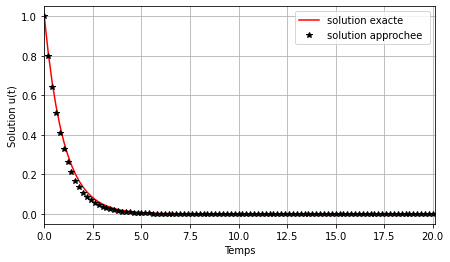

In [92]:
# Parametres de simulation
u0 = 1
T = 20
cfl = 0.1
a = 1
dt = 2 / a * cfl

# Calcul de la solution exacte par appel de "tabtemps" puis de "sol_ex_lin"
t = tabtemps(T, dt)
u_ex = sol_ex_lin(t)
# Calcul de la solution approchée par appel de la fonction "EulerExplicite"
u_app = EulerExplicite(u0, f_linear, dt, T)

# Tracé des courbes par appel de la fonction python "graphique" ci-dessus
graphique(u_app, u_ex, T, dt)

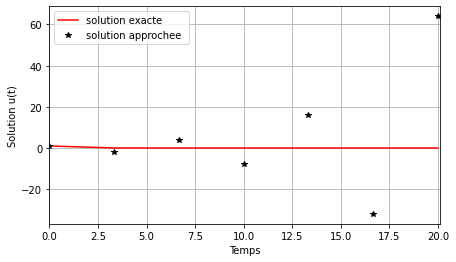

In [93]:
# Parametres de simulation
u0 = 1
T = 20
cfl = 1.5
a = 1
dt = 2 / a * cfl

# Calcul de la solution exacte par appel de "tabtemps" puis de "sol_ex_lin"
t = tabtemps(T, dt)
u_ex = sol_ex_lin(t)
# Calcul de la solution approchée par appel de la fonction "EulerExplicite"
u_app = EulerExplicite(u0, f_linear, dt, T)

# Tracé des courbes par appel de la fonction python "graphique" ci-dessus
graphique(u_app, u_ex, T, dt)

**Remarque** : avec un nombre CFL plus grand ou égal à 1, le schéma d'Euler explicite diverge, voir explose. On vient bien illustrer ici numériquement le fait que le schéma d'Euler explicite ne reste stable, et donc ne converge, que sous condition d'une CFL strictement plus petite que 1 (cad : petits pas de temps).

#### b) Cas quadratique (`f_quadra`)

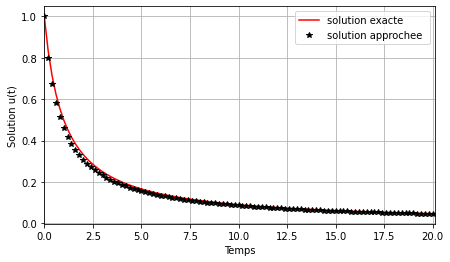

In [84]:
# Parametres de simulation
u0 = 1
T = 20
cfl = 0.1
a = 1
dt = 2 / a * cfl

# Calcul de la solution exacte par appel de "tabtemps" puis de "sol_ex_quad"
t = tabtemps(T, dt)
u_ex = sol_ex_quad(t)
# Calcul de la solution approchée par appel de la fonction "EulerExplicite"
u_app = EulerExplicite(u0, f_quadra, dt, T)

# Tracé des courbes par appel de la fonction python "graphique" ci-dessus
graphique(u_app, u_ex, T, dt)

## Partie C : Euler implicite

Le but de cette partie est maintenant d'implémenter la méthode d'Euler implicite.  
On a vu dans la partie cours que le calcul de l'itéré $u^{n+1}$ par la méthode d'Euler implicite reposait en fait sur la résolution de l'équation $(6)$ (potentiellement non linéaire si $f$ est non linéaire) :

$$(6) \quad \underbrace{\dfrac{u^{n+1}-u^n}{\Delta t} - f(u^{n+1})}_{g(u^{n+1})} = 0$$

**7)** Implémenter une fonction python `fonct_implicite` qui à partir d'une fonction mathématique $f$ donnée et des valeurs des itérés $u^{n+1}$ et $u^{n}$, renvoie la valeur $ \ g(u^{n+1}) = \dfrac{u^{n+1}-u^n}{\Delta t} - f(u^{n+1}) \ $ (membre de gauche de la relation $(6)$).

In [85]:
def fonct_implicite(u_np1, func, u_n): # garder les arguments dans cet ordre
    g = (u_np1 - u_n) / dt - func(u_np1)
    return g

**8)** Compléter la fonction python `EulerImplicite` ci-dessous. A chaque itération de votre algorithme, le calcul de l'itéré $u^{n+1}$ se fera en résolvant l'équation $(6)$. Pour cela on fera appel à une fonction existante de la librairie `scipy` (Scientific Python), à savoir la fonction `scipy.optimize.fsolve()`.

$\rightarrow$ Comment utiliser la fonction `scipy.optimize.fsolve()` ?
* arguments d'entrée : dans notre cas la fonction `fsolve` aura besoin de 3 arguments distincts (à donner dans cet ordre) :
    * 1 fonction : la fonction python implémentant la fonction mathématique $g$ (ici, ce sera `fonct_implicite`)
    * 1 valeur : la valeur avec laquelle la fonction `fsolve` doit démarrer son algorithme : on pourra mettre $u^{n}$, l'itéré calculé à l'itération précédente
    * 1 [tuple](http://www.python-simple.com/python-langage/tuple.php) (=liste d'éléments écrits entre parenthèses et non entre crochets) : ce tuple contiendra les arguments dont la fonction $g$ va avoir besoin en interne : dans notre cas la fonction $g$ aura besoin de la fonction $f$ et de la valeur de l'itéré calculé à l'itération précédente $u^{n}$ => ces 2 arguments doivent être donnés dans cet ordre dans le tuple.
* sorties :
    * la fonction `fsolve` nous donnera 1 unique sortie : il s'agit de la solution $u^{n+1}$ 
    
Pour plus de détails sur la fonction `fsolve`, voir la [documentation officielle](https://docs.scipy.org/doc/scipy-0.14.0/reference/generated/scipy.optimize.fsolve.html)

In [86]:
def EulerImplicite(u0, f, dt, T) :
    '''
    Approximation de l'EDO d'ordre 1 du cours avec la méthode 
    Euler implicite.
    Entrees :
        @u0 : solution au temps t=0
        @f : fonction f 
        @dt : pas de temps
        @T : temps final
    Sortie :
        @u : tableau contenant les valeurs de la solution 
        approchee pour tous les pas de temps
    '''
    u = []
    n = int(T / dt)
    u.append(u0)
    for i in range (0, n):
        u.append(scipy.optimize.fsolve(fonct_implicite, u[i], (f, u[i])))
    return u

**9)** Reprendre la question **6)** de la partie B pour le cas de la méthode d'Euler implicite cette fois-ci.

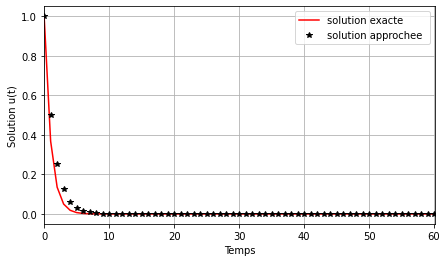

In [87]:
# Parametres de simulation
u0 = 1
T = 60
cfl = 0.5
a = 1
dt = 2 / a * cfl

# Calcul de la solution exacte par appel de "tabtemps" puis de "sol_ex_lin"
t = tabtemps(T, dt)
u_ex = sol_ex_lin(t)
# Calcul de la solution approchée par appel de la fonction "EulerExplicite"
u_app = EulerImplicite(u0, f_linear, dt, T)

# Tracé des courbes par appel de la fonction python "graphique" ci-dessus
graphique(u_app, u_ex, T, dt)

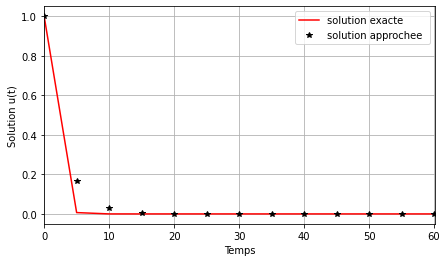

In [95]:
# Parametres de simulation
u0 = 1
T = 60
cfl = 2.5
a = 1
dt = 2 / a * cfl

# Calcul de la solution exacte par appel de "tabtemps" puis de "sol_ex_lin"
t = tabtemps(T, dt)
u_ex = sol_ex_lin(t)
# Calcul de la solution approchée par appel de la fonction "EulerExplicite"
u_app = EulerImplicite(u0, f_linear, dt, T)

# Tracé des courbes par appel de la fonction python "graphique" ci-dessus
graphique(u_app, u_ex, T, dt)

**Remarque** : avec un nombre CFL plus grand que 1, le schéma d'Euler implicite reste stable et converge toujours. On vient bien illustrer ici numériquement le fait que le schéma d'Euler implicite est **incondionnellement stable**.